In [6]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle (1).json


{'kaggle (1).json': b'{"username":"yassinsanad","key":"041fc25ae8b746ade44fc68c7a6f03a5"}'}

In [3]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [4]:
 
!kaggle datasets download -d paultimothymooney/chest-xray-pneumonia

Dataset URL: https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia
License(s): other
100% 2.29G/2.29G [00:11<00:00, 208MB/s]



In [5]:
import zipfile
import os

 
zip_ref = zipfile.ZipFile('chest-xray-pneumonia.zip', 'r')
zip_ref.extractall('/content/chest_xray_data')
zip_ref.close()

print("تم فك ضغط الداتا ست بنجاح في مجلد: /content/chest_xray_data")

تم فك ضغط الداتا ست بنجاح في مجلد: /content/chest_xray_data


In [4]:
import os
import torch
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, ConcatDataset, random_split
 
data_dir = '/content/chest_xray_data/chest_xray'  
train_dir = os.path.join(data_dir, 'train')
test_dir = os.path.join(data_dir, 'test')
val_dir = os.path.join(data_dir, 'val')

 
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomRotation(degrees=15),      
    transforms.RandomHorizontalFlip(p=0.5),   
    transforms.ColorJitter(brightness=0.2, contrast=0.2),  
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])  
])

 
test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

 
orig_train_dataset = torchvision.datasets.ImageFolder(root=train_dir, transform=train_transform)
orig_val_dataset = torchvision.datasets.ImageFolder(root=val_dir, transform=train_transform)
test_dataset = torchvision.datasets.ImageFolder(root=test_dir, transform=test_transform)

 
full_train_dataset = ConcatDataset([orig_train_dataset, orig_val_dataset])
   
train_size = int(0.85 * len(full_train_dataset))
val_size = len(full_train_dataset) - train_size

 
torch.manual_seed(42)
train_dataset, val_dataset = random_split(full_train_dataset, [train_size, val_size])

 
BATCH_SIZE = 32
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print(f"عدد صور التدريب: {len(train_dataset)}")
print(f"عدد صور التحقق (Val): {len(val_dataset)}")
print(f"عدد صور الاختبار النهائي: {len(test_dataset)}")

عدد صور التدريب: 4447
عدد صور التحقق (Val): 785
عدد صور الاختبار النهائي: 624


In [2]:
 
!pip install --upgrade pillow torchvision torch

 
!pip install scikit-learn matplotlib seaborn

In [8]:
import torch.nn as nn
import torch.optim as optim
from torchvision.models import resnet50, ResNet50_Weights

 
weights = ResNet50_Weights.DEFAULT
model = resnet50(weights=weights)

 
num_ftrs = model.fc.in_features
model.fc = nn.Sequential(
    nn.Dropout(p=0.5),  
    nn.Linear(num_ftrs, 2)
)

 
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)
 
class_weights = torch.tensor([1.8, 1.0]).to(device)

 
criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-2)  

In [9]:
import time
import copy

 
num_epochs = 10
best_model_wts = copy.deepcopy(model.state_dict())
best_loss = float('inf')

print("بدء عملية التدريب... 🚀")
print("-" * 50)

for epoch in range(num_epochs):
    start_time = time.time()

  
    model.train()   
    running_loss = 0.0
    running_corrects = 0

    for inputs, labels in train_loader:
        inputs = inputs.to(device)
        labels = labels.to(device)

        # تصفير الـ Gradients
        optimizer.zero_grad()

        # Forward pass
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)
        loss = criterion(outputs, labels)


        loss.backward()
        optimizer.step()


        running_loss += loss.item() * inputs.size(0)
        running_corrects += torch.sum(preds == labels.data)

    epoch_train_loss = running_loss / len(train_dataset)
    epoch_train_acc = running_corrects.double() / len(train_dataset)


    model.eval()
    running_val_loss = 0.0
    running_val_corrects = 0

    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            loss = criterion(outputs, labels)

            running_val_loss += loss.item() * inputs.size(0)
            running_val_corrects += torch.sum(preds == labels.data)

    epoch_val_loss = running_val_loss / len(val_dataset)
    epoch_val_acc = running_val_corrects.double() / len(val_dataset)

    epoch_time = time.time() - start_time


    print(f"Epoch {epoch+1}/{num_epochs} ({epoch_time:.0f}s):")
    print(f"  [Train] Loss: {epoch_train_loss:.4f} | Acc: {epoch_train_acc:.4f}")
    print(f"  [Val]   Loss: {epoch_val_loss:.4f} | Acc: {epoch_val_acc:.4f}")


    if epoch_val_loss < best_loss:
        best_loss = epoch_val_loss
        best_model_wts = copy.deepcopy(model.state_dict())
        print("  تم حفظ الموديل كأفضل أداء حتى الآن!")
    print("-" * 50)

print("اكتمل التدريب بنجاح! 🎉")

model.load_state_dict(best_model_wts)

torch.save(model.state_dict(), 'best_chest_xray_model.pth')
print("تم حفظ ملف الموديل النهائي باسم: best_chest_xray_model.pth")

بدء عملية التدريب... 🚀
--------------------------------------------------
Epoch 1/10 (96s):
  [Train] Loss: 0.2072 | Acc: 0.9265
  [Val]   Loss: 0.1280 | Acc: 0.9567
  🌟 تم حفظ الموديل كأفضل أداء حتى الآن!
--------------------------------------------------
Epoch 2/10 (96s):
  [Train] Loss: 0.0898 | Acc: 0.9692
  [Val]   Loss: 0.0919 | Acc: 0.9656
  🌟 تم حفظ الموديل كأفضل أداء حتى الآن!
--------------------------------------------------
Epoch 3/10 (107s):
  [Train] Loss: 0.0724 | Acc: 0.9750
  [Val]   Loss: 0.0938 | Acc: 0.9758
--------------------------------------------------
Epoch 4/10 (107s):
  [Train] Loss: 0.0533 | Acc: 0.9838
  [Val]   Loss: 0.0669 | Acc: 0.9758
  🌟 تم حفظ الموديل كأفضل أداء حتى الآن!
--------------------------------------------------
Epoch 5/10 (96s):
  [Train] Loss: 0.0482 | Acc: 0.9813
  [Val]   Loss: 0.0786 | Acc: 0.9694
--------------------------------------------------
Epoch 6/10 (95s):
  [Train] Loss: 0.0389 | Acc: 0.9872
  [Val]   Loss: 0.0597 | Acc: 0.97


تقرير الأداء النهائي (Classification Report):
              precision    recall  f1-score   support

      NORMAL       0.99      0.63      0.77       234
   PNEUMONIA       0.82      1.00      0.90       390

    accuracy                           0.86       624
   macro avg       0.91      0.81      0.84       624
weighted avg       0.88      0.86      0.85       624



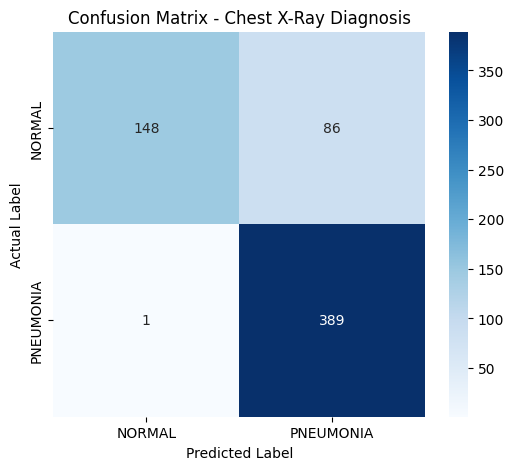

In [10]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

 
model.eval()

all_preds = []
all_labels = []
 
with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(device)
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
 
target_names = test_dataset.classes # ['NORMAL', 'PNEUMONIA']
print("\nتقرير الأداء النهائي (Classification Report):")
print(classification_report(all_labels, all_preds, target_names=target_names))


cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=target_names, yticklabels=target_names)
plt.title('Confusion Matrix - ')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

الرجاء اختيار صورة أشعة صدر لرفعها وتشخيصها... 📂


Saving download.webp to download.webp


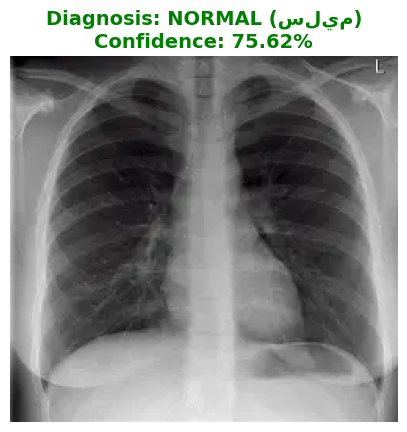

In [11]:
import torch
import torch.nn as nn
from torchvision.models import resnet50
from PIL import Image
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
from google.colab import files

 
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
inference_model = resnet50()
num_ftrs = inference_model.fc.in_features
inference_model.fc = nn.Sequential(
    nn.Dropout(p=0.5),
    nn.Linear(num_ftrs, 2)
)
 
inference_model.load_state_dict(torch.load('best_chest_xray_model.pth', map_location=device))
inference_model = inference_model.to(device)
inference_model.eval()  
 
predict_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

classes = ['NORMAL (سليم)', 'PNEUMONIA (التهاب رئوي)']

 
print("الرجاء اختيار صورة أشعة صدر لرفعها وتشخيصها... 📂")
uploaded = files.upload()

for img_name in uploaded.keys():
    # فتح الصورة ومعالجتها
    raw_image = Image.open(img_name).convert('RGB')
    input_tensor = predict_transform(raw_image).unsqueeze(0).to(device) # إضافة Batch Dimension

    # حساب التوقع
    with torch.no_grad():
        outputs = inference_model(input_tensor)
        probabilities = torch.nn.functional.softmax(outputs, dim=1)[0]
        confidence, preds = torch.max(probabilities, 0)

    # عرض النتيجة الطبية بصرياً
    plt.figure(figsize=(5, 5))
    plt.imshow(raw_image, cmap='gray')
    plt.axis('off')

   
    title_color = 'green' if preds.item() == 0 else 'red'

    plt.title(f"Diagnosis: {classes[preds.item()]}\nConfidence: {confidence.item()*100:.2f}%",
              color=title_color, fontsize=14, fontweight='bold')
    plt.show()

In [18]:
from google.colab import files

files.download('best_chest_xray_model.pth')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# التحويل الي ONNX

import torch
import torch.nn as nn
from torchvision.models import resnet50
 
device = torch.device("cpu")  
inference_model = resnet50()
num_ftrs = inference_model.fc.in_features
inference_model.fc = nn.Sequential(
 
    nn.Linear(num_ftrs, 2)
)


model_path = 'best_chest_xray_model.pth[span_4](start_span)'[span_4](end_span)
inference_model.load_state_dict(torch.load(model_path, map_location=device))[span_5](start_span)[span_5](end_span)
inference_model.eval()

 
dummy_input = torch.randn(1, 3, 224, 224)

 
onnx_model_path = "chest_xray_resnet50.onnx"
print(f"📦 جاري تحويل الموديل إلى صيغة ONNX وحفظه في: {onnx_model_path}...")

torch.onnx.export(
    inference_model,
    dummy_input,
    onnx_model_path,
    export_params=True,         
    opset_version=14,           
    do_constant_folding=True,   
    input_names=['input'],      
    output_names=['output'],    
    dynamic_axes={'input': {0: 'batch_size'}, 'output': {0: 'batch_size'}}  
)

print("✅ تم التحويل بنجاح وجاهز للتشغيل فائق السرعة!")